In [1]:

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("cleaned_telco.csv")

In [3]:
df = df.drop(columns=["customerID"])

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col
    for col in X.columns
    if col not in numeric_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [6]:
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
def evaluate_model(model, name):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    return [
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

In [9]:
logistic_results = evaluate_model(
    logistic,
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.7925
Precision: 0.6340
Recall   : 0.5187
F1 Score : 0.5706
ROC AUC  : 0.8346


In [10]:
rf_results = evaluate_model(
    rf,
    "Random Forest"
)

Random Forest
Accuracy : 0.7783
Precision: 0.6033
Recall   : 0.4840
F1 Score : 0.5371
ROC AUC  : 0.8147


In [11]:
rf_results = evaluate_model(
    rf,
    "Random Forest"
)

Random Forest
Accuracy : 0.7783
Precision: 0.6033
Recall   : 0.4840
F1 Score : 0.5371
ROC AUC  : 0.8147


In [12]:
results = pd.DataFrame(
    [
        logistic_results,
        rf_results
    ],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.792466,0.633987,0.518717,0.570588,0.834583
1,Random Forest,0.778252,0.603333,0.483957,0.537092,0.814671


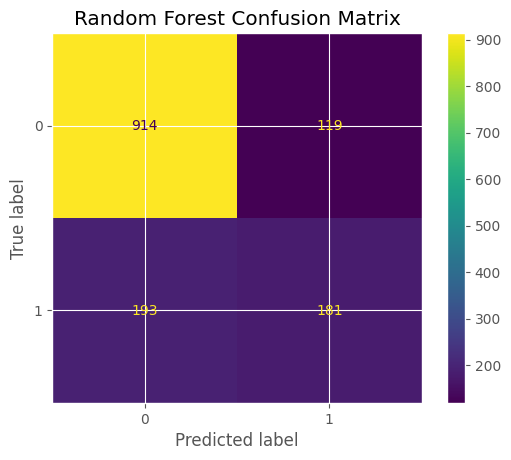

In [13]:
predictions = rf.predict(X_test)

cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

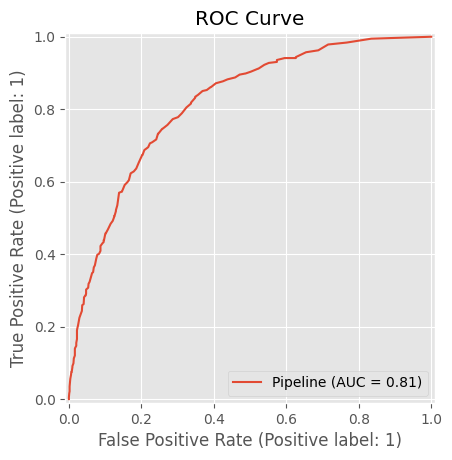

In [14]:
RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

In [15]:
rf_model = rf.named_steps["model"]

feature_names = rf.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
2,num__TotalCharges,0.140148
1,num__MonthlyCharges,0.123780
0,num__tenure,0.122441
37,cat__Contract_Month-to-month,0.045676
28,cat__TechSupport_No,0.030983
19,cat__OnlineSecurity_No,0.029171
44,cat__PaymentMethod_Electronic check,0.027321
17,cat__InternetService_Fiber optic,0.026102
46,cat__TenureGroup_0-12 Months,0.025308
4,cat__gender_Male,0.017825


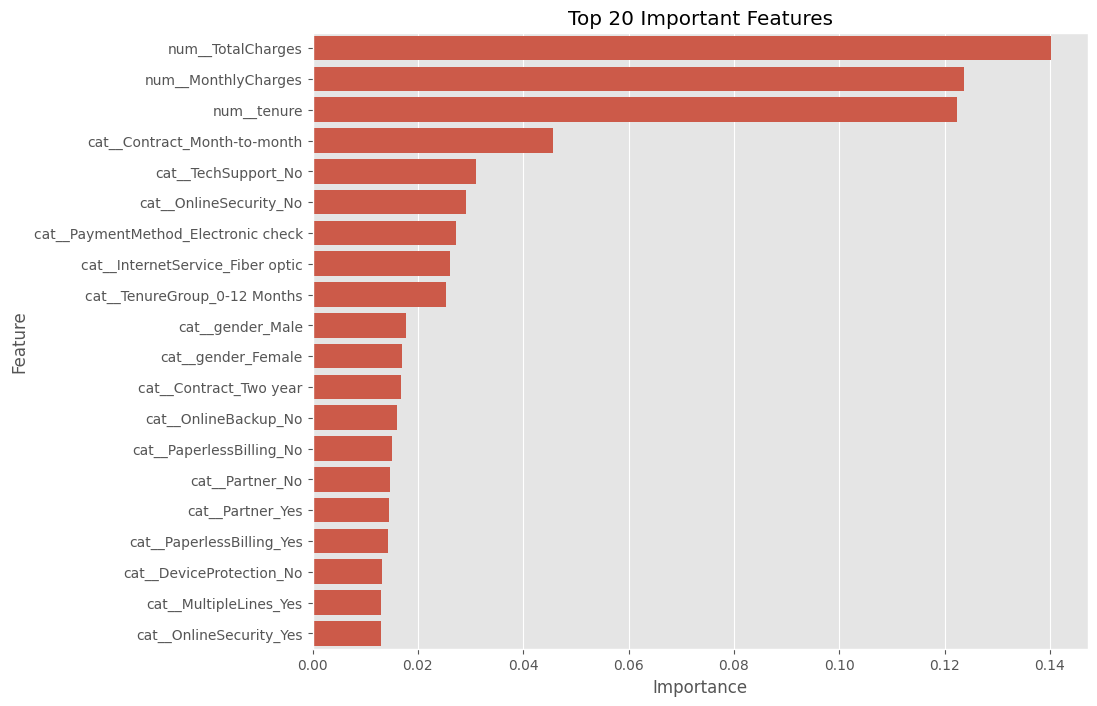

In [16]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

In [17]:
param_grid = {

    "model__n_estimators":[100,200],

    "model__max_depth":[5,10,None],

    "model__min_samples_split":[2,5]

}

grid = GridSearchCV(

    rf,

    param_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

best_model = grid.best_estimator_

print(grid.best_params_)

{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [18]:
best_results = evaluate_model(
    best_model,
    "Tuned Random Forest"
)

Tuned Random Forest
Accuracy : 0.7889
Precision: 0.6652
Recall   : 0.4144
F1 Score : 0.5107
ROC AUC  : 0.8352


In [19]:
joblib.dump(
    best_model,
    "best_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
results.loc[len(results)] = best_results

results.to_csv(
    "model_results.csv",
    index=False
)

results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.792466,0.633987,0.518717,0.570588,0.834583
1,Random Forest,0.778252,0.603333,0.483957,0.537092,0.814671
2,Tuned Random Forest,0.788913,0.665236,0.414439,0.510708,0.835180


In [21]:
print("="*70)
print("MODEL TRAINING COMPLETED")
print("="*70)

print()

print("✔ Logistic Regression Trained")

print("✔ Random Forest Trained")

print("✔ Hyperparameter Tuning Completed")

print("✔ Best Model Saved")

print("✔ Model Performance Report Saved")

MODEL TRAINING COMPLETED

✔ Logistic Regression Trained
✔ Random Forest Trained
✔ Hyperparameter Tuning Completed
✔ Best Model Saved
✔ Model Performance Report Saved
